In [29]:
# import
import polars as pl
import pyarrow as pa
import statsmodels.api as sm
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib.transforms as mtrans
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as mtick
from matplotlib import cm
from matplotlib.patches import Patch
# for using Times New Roman
import matplotlib.font_manager
import os as os
import subprocess
import sys as sys
import re
import threading
import logging
import time
import math
import warnings
warnings.filterwarnings('ignore')

In [30]:
# Using seaborn's style
plt.style.use(['ggplot', 'seaborn-v0_8-whitegrid'])

WIDTH = 345

def set_size(width, fraction=1):
    """ Set aesthetic figure dimensions to avoid scaling in latex.

    Parameters
    ----------
    width: float
            Width in pts
    fraction: float
            Fraction of the width which you wish the figure to occupy

    Returns
    -------
    fig_dim: tuple
            Dimensions of figure in inches
    """
    # Width of figure
    fig_width_pt = width * fraction

    # Convert from pt to inches
    inches_per_pt = 1 / 72.27

    # Golden ratio to set aesthetic figure height
    golden_ratio = (5**.5 - 1) / 2

    # Figure width in inches
    fig_width_in = fig_width_pt * inches_per_pt
    # Figure height in inches
    fig_height_in = fig_width_in * golden_ratio

    fig_dim = (fig_width_in, fig_height_in)

    return fig_dim

config = {
    "figure.figsize": set_size(WIDTH),
    "grid.linestyle": '--',
#     "hatch.color": '#eeeeee',
    "hatch.color": 'grey',
    "hatch.linewidth": 0.618,
    # Use LaTeX to write all text
    "text.usetex": False,
    "font.family": "Times New Roman",
    #"text.latex.unicode": True,
    "axes.unicode_minus": True,
    # Use 10pt font in plots, to match 10pt font in document
    "axes.labelsize": 22,
    "font.size": 22,
    "legend.fontsize": 22,
    # Make the label fonts a little smaller
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.handletextpad": 0.5,
    "legend.columnspacing": 0.9,
    "legend.numpoints": 3,
}

mpl.rcParams.update(config)

### comparison plot function

In [31]:
import os
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

save_pdf_path="/Users/liuyaod/daily_report/AllReduce-Tree"

def plot_prediction_error(
    p2p_df: pl.DataFrame,
    y_ticks=None,
    y_labels=None,
    figsize=(120, 24),
    pdf_filename=None,
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=True,
    legend_loc="upper center",
    legend_ncol=3,
):
    # Compute prediction error
    p2p_df = p2p_df.with_columns(
        ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() / pl.col("latency (us)")).alias("prediction_error")
    )
    df_pd = p2p_df.to_pandas()

    plt.rcParams['axes.edgecolor'] = 'black'
    plt.figure(figsize=figsize)

    for nnodes in sorted(df_pd["nnodes"].unique()):
        df_sub = df_pd[(df_pd["nnodes"] == nnodes)]
        plt.semilogx(
            df_sub["msg"],  # B
            df_sub["prediction_error"],
            marker='o',
            linestyle='None',
            label=f'{nnodes} Nodes',
            markersize=3,
            base=2
        )

    # plt.xticks([0, 131072, 17179869184], labels=["0", "128 K", "16 G"])

    # Create log2-based ticks
    x_ticks = [2**i for i in range(10, 50, 10)]  # Adjust range as needed
    x_labels = ["1 K", "1 M", "1 G", "1 T"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=0)


    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.ylim(bottom=0)
    plt.gca().yaxis.set_label_coords(-0.2, 0.4)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    if y_ticks and y_labels:
        plt.yticks(y_ticks, labels=y_labels)

    if legend:
        plt.legend(ncol=legend_ncol, loc=legend_loc, bbox_to_anchor=(0.4, -0.5),
                   handlelength=1.2, handletextpad=0, columnspacing=0)

    plt.grid(True)
    plt.tight_layout()

    if pdf_filename:
        full_path = os.path.join(save_pdf_path, pdf_filename)
        plt.savefig(full_path, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {full_path}")

    plt.show()

In [32]:
def plot_latency_comparison(
    df,
    x_col='msg',
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured Latency', 'Predicted Latency'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf'
):
    
    df = df.filter(pl.col("msg") < 18874368)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col] / 1000.0  # Convert us to ms

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(12, 25, 2)]  # Adjust range as needed
    x_labels = ["4K", "16K", "64K", "256K", "1M", "4M", "16M"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='upper left',
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

In [33]:
def plot_BW_comparison(
    df,
    x_col='msg',
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured BW', 'Predicted BW'],
    markers=['o', '^'],
    colors=['#2980b9', '#e74c3c'],
    xlabel='Message Size (Bytes)',
    ylabel='Latency (ms)',  # Changed to ms
    pdf_filename='latency_comparison.pdf'
):
    
    df = df.filter(pl.col("msg") > 16777216)

    # Convert to log scale for better visualization
    df_pandas = df.to_pandas().sort_values(by=x_col)
    
    # Convert microseconds to milliseconds
    df_pandas_ms = df_pandas.copy()
    for col in y_cols:
        df_pandas_ms[col] = df_pandas[col]

    dim = set_size(WIDTH, fraction=1)
    fig, axe = plt.subplots(figsize=dim, constrained_layout=True)

    # Plot both lines (using millisecond values)
    for y, label, marker, color in zip(y_cols, labels, markers, colors):
        axe.plot(df_pandas_ms[x_col], df_pandas_ms[y], 
                label=label, marker=marker, markersize=4, 
                color=color, linewidth=1)

    # Set log scale for x-axis
    axe.set_xscale('log', base=2)
    
    # Grid and axes settings
    axe.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

    # Create log2-based ticks
    x_ticks = [2**i for i in range(25, 34, 2)]  # Adjust range as needed
    x_labels = ["32M", "128M", "512M", "2G", "8G"]  # Separate strings with commas
    plt.xticks(x_ticks, labels=x_labels, rotation=15)

    axe.set_xlabel(xlabel)
    axe.set_ylabel(ylabel)

    # Legend
    axe.legend(
        loc='lower right',  # correct syntax
        frameon=False,
        handletextpad=0.5,
        columnspacing=1,
        handlelength=1.5
    )

    # Save to PDF if filename is provided
    if pdf_filename:
        plt.savefig(pdf_filename, format='pdf', bbox_inches='tight')
        print(f"📄 Plot saved to: {pdf_filename}")

    plt.show()

### Read from sweep data

In [34]:
import polars as pl
import pandas as pd

# Read the CSV file
df = pl.read_csv("/Users/liuyaod/daily_report/nccl-tests-all_reduce_0x0_perf.csv", has_header=False)


# Select and rename specific columns
df_sweep_data = df.select([
    pl.col("column_2").alias("msg"),           # B column
    pl.col("column_3").alias("latency (us)"),  # C column
    pl.col("column_5").alias("BW (GB/s)"),     # D column
    pl.col("column_9").alias("nnodes"),     # I column
    pl.col("column_10").alias("algorithm"),     # J column
    pl.col("column_11").alias("protocol")      # K column
])

# First group the data to calculate initial medians for comparison
initial_minis = df_sweep_data.group_by(
    ["msg", "nnodes", "algorithm", "protocol"]
).agg([
    pl.col("latency (us)").min().alias("minimum_latency"),
])

# Join the medians back to original data
df_with_minis = df_sweep_data.join(
    initial_minis,
    on=["msg", "nnodes", "algorithm", "protocol"]
)

# Filter out outliers and then calculate final medians
df_filtered = df_with_minis.filter(
    (pl.col("latency (us)") <= pl.col("minimum_latency") * 1.5)
)

# Calculate final medians after removing outliers
df_final_means = df_filtered.group_by(
    ["msg", "nnodes", "algorithm", "protocol"]
).agg([
    pl.col("latency (us)").mean().alias("latency (us)"),
    pl.col("BW (GB/s)").mean().alias("BW (GB/s)")
])

# Sort if needed
df_sweep_data_means = df_final_means.sort(["msg", "nnodes", "algorithm", "protocol"])

# Print statistics about removed outliers
total_before = len(df_sweep_data)
total_after = len(df_filtered)
print(f"Removed {total_before - total_after} outliers out of {total_before} points")

print(df_sweep_data_means)

Removed 99 outliers out of 11502 points
shape: (3_789, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 8192        ┆ 2      ┆ nvlstree  ┆ simple   ┆ 80.886667     ┆ 0.19       │
│ 8192        ┆ 2      ┆ ring      ┆ ll       ┆ 120.833333    ┆ 0.13       │
│ 8192        ┆ 2      ┆ ring      ┆ ll128    ┆ 139.533333    ┆ 0.11       │
│ 8192        ┆ 2      ┆ ring      ┆ simple   ┆ 454.933333    ┆ 0.03       │
│ 8192        ┆ 2      ┆ tree      ┆ ll       ┆ 66.243333     ┆ 0.233333   │
│ …           ┆ …      ┆ …         ┆ …        ┆ …             ┆ …          │
│ 17179869184 ┆ 128    ┆ nvlstree  ┆ simple   ┆ 106198.333333 ┆ 323.296667 │
│ 17179869184 ┆ 12

In [35]:
df_sweep_data_simple_tree = df_sweep_data_means.filter(
    (pl.col("algorithm") == "tree") & 
    (pl.col("protocol") == "simple") & 
    (pl.col("nnodes") == 16)
)

print(df_sweep_data_simple_tree)

shape: (69, 6)
┌─────────────┬────────┬───────────┬──────────┬───────────────┬────────────┐
│ msg         ┆ nnodes ┆ algorithm ┆ protocol ┆ latency (us)  ┆ BW (GB/s)  │
│ ---         ┆ ---    ┆ ---       ┆ ---      ┆ ---           ┆ ---        │
│ i64         ┆ i64    ┆ str       ┆ str      ┆ f64           ┆ f64        │
╞═════════════╪════════╪═══════════╪══════════╪═══════════════╪════════════╡
│ 8192        ┆ 16     ┆ tree      ┆ simple   ┆ 331.55        ┆ 0.05       │
│ 16384       ┆ 16     ┆ tree      ┆ simple   ┆ 348.4         ┆ 0.09       │
│ 32768       ┆ 16     ┆ tree      ┆ simple   ┆ 360.7         ┆ 0.18       │
│ 65536       ┆ 16     ┆ tree      ┆ simple   ┆ 369.933333    ┆ 0.35       │
│ 131072      ┆ 16     ┆ tree      ┆ simple   ┆ 420.3         ┆ 0.633333   │
│ …           ┆ …      ┆ …         ┆ …        ┆ …             ┆ …          │
│ 6979321856  ┆ 16     ┆ tree      ┆ simple   ┆ 47517.333333  ┆ 291.466667 │
│ 7516192768  ┆ 16     ┆ tree      ┆ simple   ┆ 51007.0      

### Model Varification V0

📄 Plot saved to: /Users/liuyaod/daily_report/AllReduce-Tree/allreduce_tree_simple_pre_error_v0.pdf


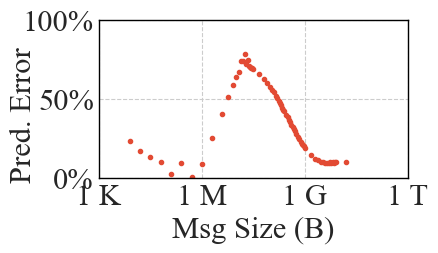

In [36]:
# use last chunk's T0 as the total communication time to calculate the G, only use the G to predict the latency when only consider the inter node latency.

number_nodes = 16
gpus_per_node = 8

df_sweep_data_simple_tree_v0 = df_sweep_data_simple_tree.with_columns([
    (((13/255)*8*1000) + ((13/255)*1000) * pl.col("msg") / (8*1024*1024)).alias("latency_pre (us)")
])

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v0 = df_sweep_data_simple_tree_v0.with_columns([
    (pl.col("msg") * 0.001 * (2*(number_nodes * gpus_per_node - 1)/(number_nodes * gpus_per_node)) / pl.col("latency_pre (us)")).alias("BW_pre (GB/s)")
])

# with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
#         print(df_sweep_data_simple_tree_v0.to_pandas())

# Then, create the bandwidth column using the newly created latency column
df_sweep_data_simple_tree_v0_csv = df_sweep_data_simple_tree_v0.with_columns([
    ((pl.col("latency_pre (us)") - pl.col("latency (us)")).abs() * 100 / pl.col("latency (us)")).alias("prediction_error (%)")
])

df_sweep_data_simple_tree_v0_csv.to_pandas().to_csv('model0.csv', index=False)

plot_prediction_error(
    df_sweep_data_simple_tree_v0,
    figsize=(5, 3),
    pdf_filename="allreduce_tree_simple_pre_error_v0.pdf",
    y_ticks=[0.0, 0.50, 1.00],
    y_labels=["0%", "50%", "100%"],
    xlabel="Msg Size (B)",
    ylabel="Pred. Error",
    legend=False
)

📄 Plot saved to: allreduce_tree_simple_pre_comparison_v0.pdf


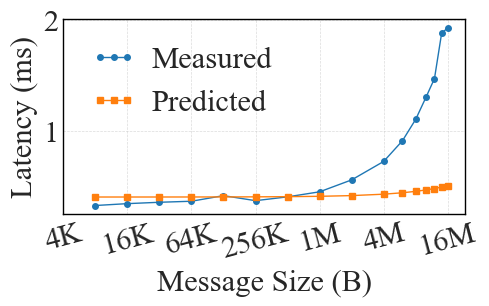

In [37]:
plot_latency_comparison(
    df=df_sweep_data_simple_tree_v0,
    y_cols=['latency (us)', 'latency_pre (us)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='Latency (ms)',
    pdf_filename='allreduce_tree_simple_pre_comparison_v0.pdf' 
)

📄 Plot saved to: allreduce_tree_simple_BW_pre_comparison_v0.pdf


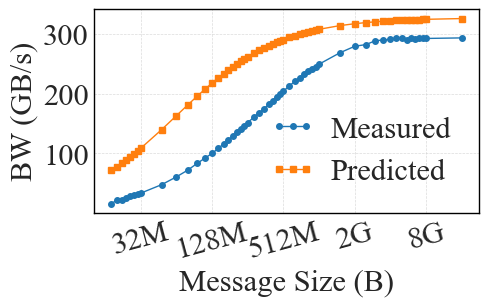

In [38]:
plot_BW_comparison(
    df=df_sweep_data_simple_tree_v0,
    y_cols=['BW (GB/s)', 'BW_pre (GB/s)'],
    labels=['Measured', 'Predicted'],
    markers=['o', 's'],
    colors=['#1f77b4', '#ff7f0e'],
    xlabel='Message Size (B)',
    ylabel='BW (GB/s)',
    pdf_filename='allreduce_tree_simple_BW_pre_comparison_v0.pdf' 
)

### Read from profiling

In [39]:

import re
import polars as pl

def parse_send_timings(filename: str) -> pl.DataFrame:
    with open(filename, 'r') as f:
        text = f.read()

    # 1) find all the INFO headers
    info_re = re.compile(
        r"INFO: protocol\((?P<protocol>Simple|LL|LL128)\)_mode\(allreduce\)_message size\((?P<message_size>\d+)\)"
        r"_nchannels\((?P<nchannels>\d+)\)"
        r"_nmessages\((?P<nmessages>\d+)\)"
        r"_iteration\((?P<iteration>\d+)\)"
    )
    info_matches = list(info_re.finditer(text))

    # Pattern for T0-T7 style chunks
    chunk_re = re.compile(
        r"-- \[T(?P<tag>[07])\] chunk (?P<chunk_id>\d+).*?"
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Additional pattern for T10 style chunks
    chunk_t10_re = re.compile(
        r"-- \[T(?P<tag>10)\] chunk 0 posted to chunk (?P<chunk_id>\d+) done time "
        r"\(r(?P<source>\d+) to r(?P<dest>\d+)\) in channel (?P<channel>\d+): (?P<value>[\d.]+) ms"
    )

    # Rest of the patterns remain the same
    t_tags_re = re.compile(
        r"-- \[T(?P<tag>[1289])\].*?time: (?P<value>[\d.]+) ms"
    )
    
    t_total_re = re.compile(
        r"-- \[T total\] nccl allreduce elapsed time by clock: (?P<value>[\d.]+) ms"
    )

    records = []
    for idx, m in enumerate(info_matches):
        meta = m.groupdict()  # Get all groups as strings first
        # Convert only numeric fields to int, keep protocol as string
        for k in ['message_size', 'nchannels', 'nmessages', 'iteration']:
            meta[k] = int(meta[k])
        start = m.end()
        end = info_matches[idx+1].start() if idx+1 < len(info_matches) else len(text)
        section = text[start:end]

        # Get T1, T2, T8, T9 timings
        t_timings = {
            f"T{e.group('tag')}": float(e.group('value'))
            for e in t_tags_re.finditer(section)
        }

        # Get total time
        tm = t_total_re.search(section)
        if tm:
            t_timings["T_total"] = float(tm.group("value"))

        # Process chunk data
        chunk_data = {}
        for c in chunk_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))  # Extract source from regex
            dest = int(c.group('dest'))      # Extract dest from regex
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,  # Use extracted values
                    "dest": dest,      # Use extracted values
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        # Process T10 chunks
        for c in chunk_t10_re.finditer(section):
            cid = int(c.group("chunk_id"))
            ch = int(c.group("channel"))
            tag = f"T{c.group('tag')}"
            val = float(c.group('value'))
            source = int(c.group('source'))
            dest = int(c.group('dest'))
            
            key = (cid, ch, meta["iteration"])
            if key not in chunk_data:
                chunk_data[key] = {
                    "chunk_id": cid,
                    "channel": ch,
                    "source": source,
                    "dest": dest,
                    **meta,
                    **t_timings
                }
            chunk_data[key][tag] = val

        records.extend(chunk_data.values())

    df = pl.DataFrame(records)
    print(f"Number of records: {len(records)}")  # Debug print
    return df

In [40]:
# === File Paths ===
profiling_files = {
    "r0": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-0.out",
    "r8": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-8.out",
    "r16": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-16.out",
    "r17": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-17.out",
    "r24": "/Users/liuyaod/daily_report/AllReduce-Tree/simple_profiling_results/nccl_allreduce_heo-inter_r-24.out",
}

# === Load Data ===
df_r0 = parse_send_timings(profiling_files["r0"])
df_r8 = parse_send_timings(profiling_files["r8"])
df_r16 = parse_send_timings(profiling_files["r16"])
df_r17 = parse_send_timings(profiling_files["r17"])
df_r24 = parse_send_timings(profiling_files["r24"])

dataframes = {
    "r0": df_r0,
    "r8": df_r8,
    "r16": df_r16,
    "r17": df_r17,
    "r24": df_r24
}


Number of records: 142
Number of records: 142
Number of records: 284
Number of records: 142
Number of records: 142


In [41]:
import pandas as pd

def calculate_df_means(dataframes_dict):
    """
    Calculate means for multiple dataframes.
    
    Args:
        dataframes_dict: Dictionary of dataframes with their names as keys
                        e.g., {"r0": df_r0, "r8": df_r8, ...}
    
    Returns:
        Dictionary of processed dataframes with their names as keys
    """
    results = {}


    
    for name, df in dataframes_dict.items():
        # Group by everything except iteration to find minimum T10 values
        min_t10 = (df
            .group_by(["message_size", "source", "dest", "chunk_id"])
            .agg([
                pl.col("T10").min().alias("min_T10")
            ])
        )
        
        # Join back to original dataframe and filter out T10 values > 2*min
        df_filtered = (df
            .join(min_t10, on=["message_size", "source", "dest", "chunk_id"])
            .filter(pl.col("T10") <= 2 * pl.col("min_T10"))
        )

        mean_df = (df_filtered
            .select([
                "chunk_id", "T8", "T9", "T10", "T0", 
                "source", "dest", "message_size", "iteration"
            ])
            .group_by("message_size", "source", "dest", "chunk_id")
            .agg([
                pl.col("T8").mean().alias("T8_mean"),
                pl.col("T9").mean().alias("T9_mean"),
                pl.col("T10").mean().alias("T10_mean"),
                pl.col("T0").mean().alias("T0_mean")
            ])
            .sort(["message_size", "chunk_id"])
        )
        results[f"{name}_mean"] = mean_df
    
    return results

means = calculate_df_means(dataframes)

# Access individual results:
df_r0_mean = means["r0_mean"]
df_r8_mean = means["r8_mean"]
df_r16_mean = means["r16_mean"]
df_r17_mean = means["r17_mean"]
df_r24_mean = means["r24_mean"]

df_r16_up_mean = df_r16_mean.filter(pl.col("dest") == 0)

df_r16_down_mean = df_r16_mean.filter(pl.col("dest") == 24)


for name, df in means.items():
    with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', 1000):
        print(df.to_pandas())


     message_size  source  dest  chunk_id   T8_mean   T9_mean  T10_mean   T0_mean
0               8       0    16         0  0.039205  0.168025  0.152945  0.000000
1              16       0    16         0  0.033155  0.159438  0.146247  0.000000
2              32       0    16         0  0.032265  0.184031  0.170487  0.000000
3              64       0    16         0  0.033658  0.185953  0.170482  0.000000
4             128       0    16         0  0.082354  0.177931  0.163509  0.000000
5             256       0    16         0  0.089848  0.185410  0.170490  0.000000
6            1024       0    16         0  0.189463  0.134839  0.115117  0.000000
7            2048       0    16         0  0.225936  0.154351  0.136821  0.000000
8            3072       0    16         0  0.207925  0.228699  0.212666  0.000000
9            4096       0    16         0  0.248121  0.252306  0.236706  0.000000
10           5120       0    16         0  0.350964  0.214731  0.198318  0.000000
11           614

### Some Analysis

In [42]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_chunk_timing(df, message_size, plot_figure):
    # (MB/ms = GB/s)
    
    df_filtered = df.filter(
        (pl.col("message_size") == message_size) & 
        (pl.col("chunk_id") < 100)
    )
    
    # Calculate differences in T10_mean
    T10_diff = []
    chunk_ids = []
    chunk_id_diff = []
    for i in range(1, len(df_filtered)):
        current_chunk_id = df_filtered['chunk_id'][i]
        prev_chunk_id = df_filtered['chunk_id'][i-1]
        current_T10 = df_filtered['T10_mean'][i]
        prev_T10 = df_filtered['T10_mean'][i-1]
        T10_diff.append(current_T10 - prev_T10)
        chunk_id_diff.append(current_chunk_id - prev_chunk_id)
        chunk_ids.append(df_filtered['chunk_id'][i])
    
    # Convert to numpy arrays
    X = np.array(chunk_ids).reshape(-1, 1)
    y = (16 * 0.5 * np.array(chunk_id_diff) / np.array(T10_diff))

    median_T10_diff = np.median(y)
    
    if plot_figure:
        # Perform linear regression
        reg = LinearRegression().fit(X, y)
        k = reg.coef_[0]  # slope
        s = reg.intercept_  # intercept
        r2 = reg.score(X, y)  # R-squared value
        
        # Create plot
        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, color='blue', label='Actual data')
        plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
        plt.xlabel('Chunk ID')
        plt.ylabel('Processing Speed (GB/s)')
        plt.title(f'(Chunk Size / t_i) vs Chunk ID (R² = {r2:.4f})')
        plt.legend()
        plt.grid(True)
        plt.show()
    
    return median_T10_diff

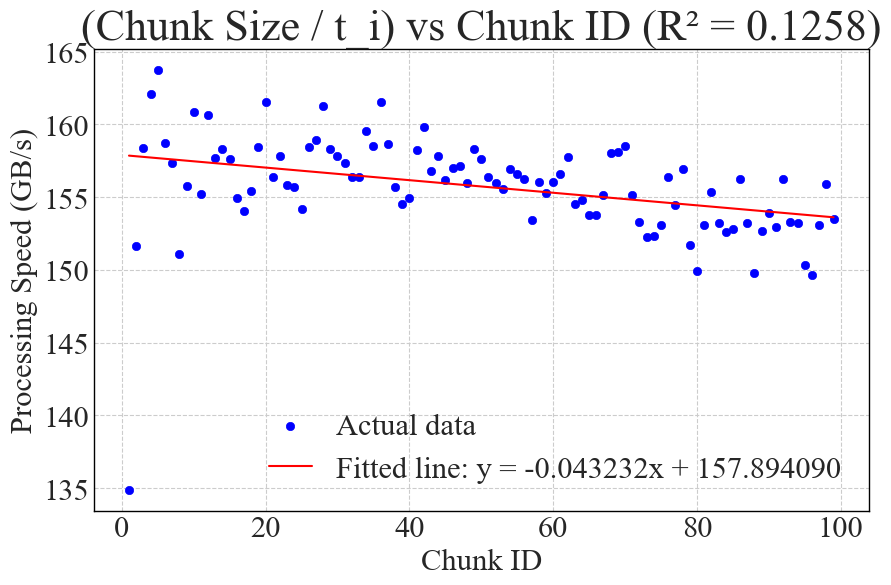

Median of the chunk processing speed is:  156.009283 GB/s


In [43]:
# Use the function
G = analyze_chunk_timing(df_r17_mean, 8388608, 1)
print(f"Median of the chunk processing speed is: {G: 3f} GB/s")

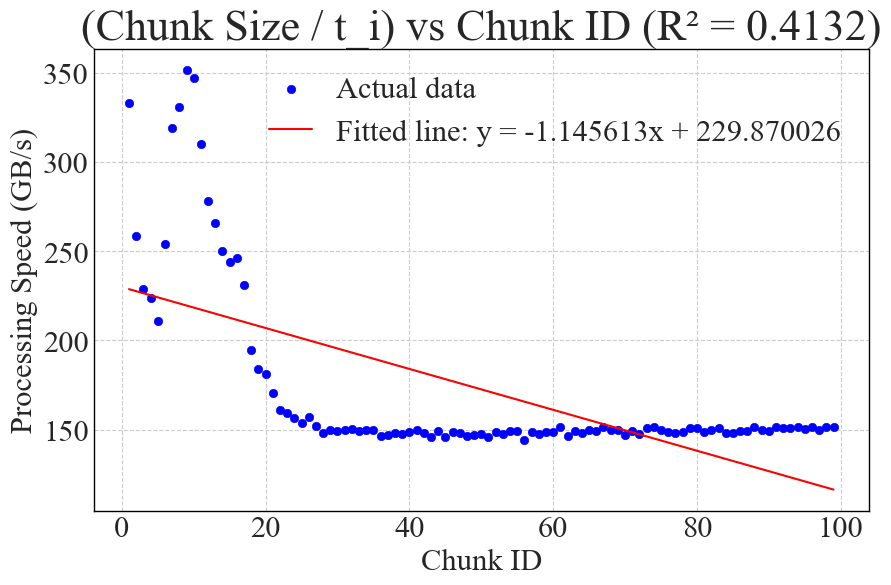

Median of the chunk processing speed is:  149.709003 GB/s


In [44]:
# Use the function
G = analyze_chunk_timing(df_r8_mean, 8388608, 1)
print(f"Median of the chunk processing speed is: {G: 3f} GB/s")

In [45]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

def analyze_message_timing(df, min_message_size, max_message_size):
    # (KB/ms = 0.001 GB/s)    
    
    df_filtered = df.filter(
     (pl.col("message_size") >= min_message_size) & 
     (pl.col("message_size") < max_message_size)
    )

    # Get max chunk_id for each message_size
    max_chunks = (df_filtered
        .group_by("message_size")
        .agg(pl.col("chunk_id").max().alias("max_chunk_id"))
    )

    # Join back to get rows with max chunk_id for each message_size
    df_filtered = (df_filtered
        .join(max_chunks, on="message_size")
        .filter(pl.col("chunk_id") == pl.col("max_chunk_id"))
        .drop("max_chunk_id")
        .sort("message_size")
    )
    
    # Calculate X and y
    X = (df_filtered['message_size'] * 0.001).to_numpy().reshape(-1, 1)
    y = (df_filtered['message_size'] * 0.001 / 
         (df_filtered['T10_mean'])).to_numpy()
    
    # Perform linear regression
    reg = LinearRegression().fit(X, y)
    k = reg.coef_[0]  # slope
    s = reg.intercept_  # intercept
    r2 = reg.score(X, y)  # R-squared value
    
    # Create plot
    plt.figure(figsize=(10, 6))
    plt.scatter(X, y, color='blue', label='Actual data')
    plt.plot(X, reg.predict(X), color='red', label=f'Fitted line: y = {k:.6f}x + {s:.6f}')
    plt.xlabel('Message Size (MB)')
    plt.ylabel('Processing Speed (GB/s)')
    plt.title(f'(Chunk Size / t_i) vs Message Size (R² = {r2:.4f})')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return k, s, r2

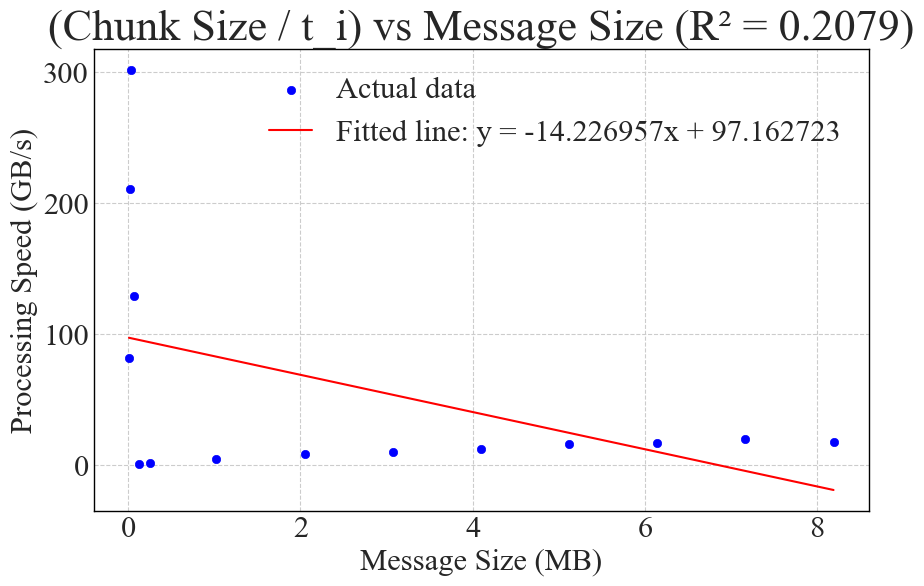

Linear equation: 0.5/T7_mean = -14.226957 * chunk_id + 97.162723
R-squared value: 0.2079


In [46]:
# Use the function
k, s, r2 = analyze_message_timing(df_r17_mean, 2, 9216)
print(f"Linear equation: 0.5/T7_mean = {k:.6f} * chunk_id + {s:.6f}")
print(f"R-squared value: {r2:.4f}")

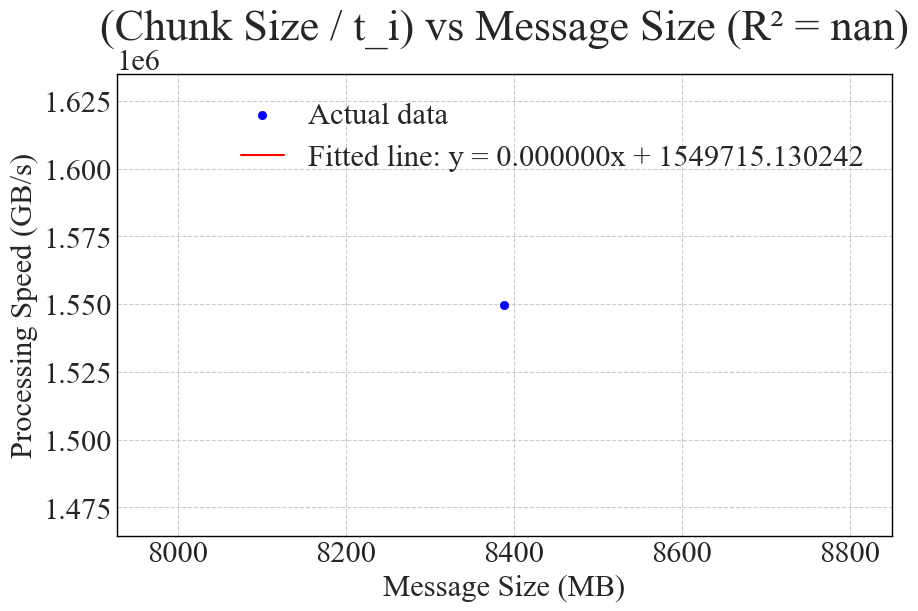

Linear equation: 0.5/T7_mean = 0.000000 * chunk_id + 1549715.130242
R-squared value: nan


In [47]:
# Use the function
k, s, r2 = analyze_message_timing(df_r17_mean, 131072, 33554432)
print(f"Linear equation: 0.5/T7_mean = {k:.6f} * chunk_id + {s:.6f}")
print(f"R-squared value: {r2:.4f}")

In [48]:
message_size_for_G = 16777216

G = min(analyze_chunk_timing(df_r0_mean, message_size_for_G, 0),
        analyze_chunk_timing(df_r8_mean, message_size_for_G, 0),
        analyze_chunk_timing(df_r16_up_mean, message_size_for_G, 0),
        analyze_chunk_timing(df_r16_down_mean, message_size_for_G, 0),
        analyze_chunk_timing(df_r17_mean, message_size_for_G, 0),
        analyze_chunk_timing(df_r24_mean, message_size_for_G, 0)
        )

print(f"the G for the tree is {G: 3f} GB/s")

the G for the tree is  nan GB/s


In [49]:

# # t_i represents the maximum chunk processing time among all inter-node peer-to-peer communications in the tree.

# # t_i_0 represents the maximum chunk processing time among all inter-node peer-to-peer communications in the tree.

# T_AllReduce_simple_tree_reduce = (N_gpus_per_node - 1) * L_reduce_intra + (t_i_0 + L + L_reduce_intra) * (math.log2(N_nodes) - 1) +  t_i_0 + L 

# T_AllReduce_simple_tree_broadcast = t_i_0 + L + (t_i_0 + L + L_bc_intra) * (math.log2(N_nodes) - 1) + (N_gpus_per_node - 1) * L_bc_intra

# T_AllReduce_simple_tree_addition_chunks = t_i * C * (N_ck/N_ch - 1)

# T_AllReduce_simple_tree = T_AllReduce_simple_tree_reduce + T_AllReduce_simple_tree_broadcast + T_AllReduce_simple_tree_addition_chunks

## p2p

In [50]:
# ### simple
# T_p2p_simple = (o_i + o_l + o_f + o_sc) * C_o  + max(S_ck * G * C_G , o_sc * C_o) * (N_ck/N_ch - 1) + L

# ### LL
# T_p2p_LL = (o_i + o_l + o_f + o_sc) * C_o  + max(2 * S_ck * G * C_G , o_sc * C_o) * (N_ck/N_ch - 1) + L

# ### LL128
# T_p2p_LL = (o_i + o_l + o_f + o_sc) * C_o  + max((1/0.95) * S_ck * G * C_G , o_sc * C_o) * (N_ck/N_ch - 1) + L

## AllReduce

### Simple, Tree

In [51]:
# T_AllReduce_simple_tree_reduce = (o_i + o_l + o_f) * C_o + (N_gpus_per_node - 1) * L_reduce_intra + (max(o_sc_rrs * C_o, S_ck * G_rrs * C_G) + L + L_reduce_intra) * (math.log2(N_nodes) - 1) +  max(o_sc_rrs * C_o, S_ck * G_rrs * C_G) + L 

# T_AllReduce_simple_tree_broadcast = max(o_sc_send * C_o, S_ck * G_send * C_G) + L + (max(o_sc_rcs * C_o, S_ck * G_rcs * C_G) + L + L_bc_intra) * (math.log2(N_nodes) - 1) + (N_gpus_per_node - 1) * L_bc_intra

# T_AllReduce_simple_tree_addition_chunks = max(S_ck * G_rrs * C_G , o_sc_rrs * C_o, S_ck * G_rcs * C_G, o_sc_rcs * C_o) * (N_ck/N_ch - 1)

# T_AllReduce_simple_tree = T_AllReduce_simple_tree_reduce + T_AllReduce_simple_tree_broadcast + T_AllReduce_simple_tree_addition_chunks

### LL, TREE

In [52]:
# T_AllReduce_LL_tree_reduce = (o_i + o_l + o_f) * C_o + (N_gpus_per_node - 1) * L_reduce_intra + (max(o_sc_rrs * C_o, 2 * S_ck * G_rrs * C_G) + L + L_reduce_intra) * (math.log2(N_nodes) - 1) +  max(o_sc_rrs * C_o, 2 * S_ck * G_rrs * C_G) + L 

# T_AllReduce_LL_tree_broadcast = max(o_sc_send * C_o, 2 * S_ck * G_send * C_G) + L + (max(o_sc_rcs * C_o, 2 * S_ck * G_rcs * C_G) + L + L_bc_intra) * (math.log2(N_nodes) - 1) + (N_gpus_per_node - 1) * L_bc_intra

# T_AllReduce_LL_tree_addition_chunks = max(2 * S_ck * G_rrs * C_G , o_sc_rrs * C_o, 2 * S_ck * G_rcs * C_G, o_sc_rcs * C_o) * (N_ck/N_ch - 1)

# T_AllReduce_LL_tree = T_AllReduce_LL_tree_reduce + T_AllReduce_LL_tree_broadcast + T_AllReduce_LL_tree_addition_chunks

### LL128, TREE

In [53]:
# T_AllReduce_LL128_tree_reduce = (o_i + o_l + o_f) * C_o + (N_gpus_per_node - 1) * L_reduce_intra + (max(o_sc_rrs * C_o, (1/0.95) * S_ck * G_rrs * C_G) + L + L_reduce_intra) * (math.log2(N_nodes) - 1) +  max(o_sc_rrs * C_o, (1/0.95) * S_ck * G_rrs * C_G) + L 

# T_AllReduce_LL128_tree_broadcast = max(o_sc_send * C_o, (1/0.95) * S_ck * G_send * C_G) + L + (max(o_sc_rcs * C_o, (1/0.95) * S_ck * G_rcs * C_G) + L + L_bc_intra) * (math.log2(N_nodes) - 1) + (N_gpus_per_node - 1) * L_bc_intra

# T_AllReduce_LL128_tree_addition_chunks = max((1/0.95) * S_ck * G_rrs * C_G , o_sc_rrs * C_o, (1/0.95) * S_ck * G_rcs * C_G, o_sc_rcs * C_o) * (N_ck/N_ch - 1)

# T_AllReduce_LL128_tree = T_AllReduce_LL128_tree_reduce + T_AllReduce_LL128_tree_broadcast + T_AllReduce_LL128_tree_addition_chunks

### Simple, RING

In [54]:
# T_AllReduce_simple_ring_o = (o_i + o_l + o_f) * C_o

# T_AllReduce_simple_ring_rs = max(o_sc_send * C_o, S_ck * G_send * C_G) + L + (max(o_sc_rrs * C_o, S_ck * G_rrs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rrcs * C_o, S_ck * G_rrcs * C_G) + L

# T_AllReduce_simple_ring_ag= (max(o_sc_rcs * C_o, S_ck * G_rcs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rcv * C_o, S_ck * G_rcv * C_G) + L

# T_AllReduce_simple_ring = T_AllReduce_simple_ring_o + (T_AllReduce_simple_ring_rs + T_AllReduce_simple_ring_ag) * (N_ck/(N_gpus_per_node * N_nodes))

### LL, RING

In [55]:
# T_AllReduce_LL_ring_o = (o_i + o_l + o_f) * C_o

# T_AllReduce_LL_ring_rs = max(o_sc_send * C_o, 2 * S_ck * G_send * C_G) + L + (max(o_sc_rrs * C_o, 2 * S_ck * G_rrs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rrcs * C_o, 2 * S_ck * G_rrcs * C_G) + L

# T_AllReduce_LL_ring_ag= (max(o_sc_rcs * C_o, 2 * S_ck * G_rcs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rcv * C_o, 2 * S_ck * G_rcv * C_G) + L

# T_AllReduce_LL_ring = T_AllReduce_LL_ring_o + (T_AllReduce_LL_ring_rs + T_AllReduce_LL_ring_ag) * (N_ck/(N_gpus_per_node * N_nodes))

### LL128, RING

In [56]:
# T_AllReduce_LL128_ring_o = (o_i + o_l + o_f) * C_o

# T_AllReduce_LL128_ring_rs = max(o_sc_send * C_o, (1/0.95) * S_ck * G_send * C_G) + L + (max(o_sc_rrs * C_o, (1/0.95) * S_ck * G_rrs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rrcs * C_o, (1/0.95) * S_ck * G_rrcs * C_G) + L

# T_AllReduce_LL128_ring_ag= (max(o_sc_rcs * C_o, (1/0.95) * S_ck * G_rcs * C_G) + L) * (N_gpus_per_node * N_nodes - 2) + max(o_sc_rcv * C_o, (1/0.95) * S_ck * G_rcv * C_G) + L

# T_AllReduce_LL128_ring = T_AllReduce_LL_ring_o + (T_AllReduce_LL_ring_rs + T_AllReduce_LL_ring_ag) * (N_ck/(N_gpus_per_node * N_nodes))